# Fooling LIME and SHAP — Replicación con Adult Income Dataset

Replicación del experimento de **Slack et al. (2020)** *"Fooling LIME and SHAP: Adversarial Attacks on Post hoc Explanation Methods"* aplicado al dataset **Adult Income**.

## Idea central del paper

Se construye un **clasificador adversario** que:
1. Se comporta como un modelo **racista/sesgado** en producción (usa atributos sensibles como `race` y `sex`).
2. Detecta cuándo está siendo inspeccionado por LIME o SHAP (las instancias de explicación son distribucionales distintas a los datos reales).
3. Devuelve predicciones de un **modelo inocente** (sin atributos sensibles) cuando detecta la inspección.

El resultado: LIME y SHAP reportan que el modelo **no usa atributos discriminatorios**, cuando en realidad sí lo hace.

---
## Pipeline
```
Datos reales ──► Perturbador (LIME/SHAP)  ──► ¿Es instancia perturbada?
                                                    │
                                         Sí ◄───────┤───────► No
                                          │                    │
                                   Modelo inocente      Modelo sesgado
                                   (sin race/sex)       (con race/sex)
```

## 0. Imports y configuración

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_auc_score, confusion_matrix)

import lime
import lime.lime_tabular
import shap

from scipy.spatial.distance import cdist

SEED = 42
np.random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = {'biased': '#e63946', 'innocuous': '#457b9d', 'adversarial': '#2d6a4f'}

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga y preprocesamiento del dataset

> Pega aquí el código de carga que ya tienes. Las celdas siguientes asumen que existen:
> `X_train`, `X_test`, `y_train`, `y_test`, `feature_names`, `num_features`, `cat_features`

In [2]:
# ── Pega aquí tu código de carga y preprocesamiento ──────────────────────────
# (el bloque que va desde DATA_PATH hasta el print final)
# ─────────────────────────────────────────────────────────────────────────────
# ruta a la carpeta con adult.data y adult.test
DATA_PATH = 'adult_data/'

col_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

train_raw = pd.read_csv(DATA_PATH + 'adult.data', names=col_names,
                        sep=', ', engine='python', na_values='?')
test_raw  = pd.read_csv(DATA_PATH + 'adult.test', names=col_names,
                        sep=', ', engine='python', na_values='?', skiprows=1)

# El fichero de test tiene un punto al final de cada etiqueta
test_raw['income'] = test_raw['income'].str.replace('.', '', regex=False)

df_raw = pd.concat([train_raw, test_raw], ignore_index=True)

print(f"Instancias totales : {df_raw.shape[0]:,}")
print(f"Variables          : {df_raw.shape[1]}")
print(f"Valores ausentes:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print(f"\nDistribucion del target:")
print(df_raw['income'].value_counts())

num_features = ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss']
cat_features = ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex']
feature_names = num_features + cat_features

# Seleccion y limpieza
df = df_raw[feature_names + ['income']].dropna().copy()
df['income'] = (df['income'] == '>50K').astype(int)

print(f"Instancias tras eliminar ausentes: {df.shape[0]:}")
print(f"Tasa >50K: {df['income'].mean():.1%}")

# Codificacion de categoricas
df_enc  = df.copy()
le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col])
    le_dict[col] = le

X = df_enc[feature_names]
y = df_enc['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Train: {X_train.shape[0]:} | Test: {X_test.shape[0]:}")

# Verificación rápida
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Features: {feature_names}')
print(f'Sensibles: race → índice {feature_names.index("race")}, '
      f'sex → índice {feature_names.index("sex")}')

Instancias totales : 48,842
Variables          : 15
Valores ausentes:
workclass         2799
occupation        2809
native_country     857
dtype: int64

Distribucion del target:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64
Instancias tras eliminar ausentes: 46033
Tasa >50K: 24.8%
Train: 36826 | Test: 9207
X_train: (36826, 11)  |  X_test: (9207, 11)
Features: ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 'workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex']
Sensibles: race → índice 9, sex → índice 10


## 2. Definición de atributos sensibles e inocuos

Siguiendo el paper, separamos las features en:
- **Sensibles**: `race`, `sex` — no deben usarse éticamente.
- **Inocuas**: el resto — permitidas para predecir.

In [3]:
sensitive_features = ['race', 'sex']
innocuous_features = [f for f in feature_names if f not in sensitive_features]

# Índices en X
sens_idx  = [feature_names.index(f) for f in sensitive_features]
innoc_idx = [feature_names.index(f) for f in innocuous_features]

print(f'Features sensibles  ({len(sensitive_features)}): {sensitive_features}')
print(f'Features inocuas    ({len(innocuous_features)}): {innocuous_features}')

# Subconjuntos de datos (solo features inocuas)
X_train_innoc = X_train[innocuous_features].values
X_test_innoc  = X_test[innocuous_features].values
X_train_all   = X_train.values
X_test_all    = X_test.values

Features sensibles  (2): ['race', 'sex']
Features inocuas    (9): ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 'workclass', 'marital_status', 'occupation', 'relationship']


## 3. Entrenamiento de los clasificadores base

### 3.1 Modelo sesgado (*biased classifier* $f_b$)
Usa **todas** las features, incluidas `race` y `sex`. Simula el comportamiento real del sistema en producción.

### 3.2 Modelo inocuo (*innocuous classifier* $f_i$)
Solo usa las features **no sensibles**. Es el modelo que se muestra durante la auditoría.

In [ ]:
# ── 3.1 Clasificador sesgado ─────────────────────────────────────────────────
clf_biased = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
clf_biased.fit(X_train_all, y_train)

acc_b = accuracy_score(y_test, clf_biased.predict(X_test_all))
auc_b = roc_auc_score(y_test, clf_biased.predict_proba(X_test_all)[:, 1])
print(f'Clasificador SESGADO  — Acc: {acc_b:.4f} | AUC: {auc_b:.4f}')

# Importancia de features
fi_biased = pd.Series(clf_biased.feature_importances_, index=feature_names).sort_values(ascending=False)
print('\nTop-5 features más importantes (modelo sesgado):')
print(fi_biased.head())

ValueError: X has 11 features, but RandomForestClassifier is expecting 2 features as input.

In [7]:
# 1. ¿Están race y sex en X_train?
print(X_train.columns.tolist())

# 2. ¿Cuántos valores únicos tienen? (si son constantes, RF las ignora)
print(X_train['race'].value_counts())
print(X_train['sex'].value_counts())

# 3. ¿Qué índices ocupan en feature_names?
print(feature_names)
print(f"race → índice {feature_names.index('race')}")
print(f"sex  → índice {feature_names.index('sex')}")

# 4. Importancia completa ordenada
fi_full = pd.Series(clf_biased.feature_importances_, index=feature_names).sort_values(ascending=False)
print(fi_full)

['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 'workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex']
race
4    31559
2     3482
1     1167
0      331
3      287
Name: count, dtype: int64
sex
1    24882
0    11944
Name: count, dtype: int64
['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 'workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex']
race → índice 9
sex  → índice 10
age               0.219988
education_num     0.137781
capital_gain      0.129691
relationship      0.124946
hours_per_week    0.111871
occupation        0.083230
marital_status    0.070104
workclass         0.047839
capital_loss      0.043358
race              0.019955
sex               0.011237
dtype: float64


In [8]:
# ── 3.2 Clasificador inocuo ──────────────────────────────────────────────────
clf_innocuous = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
clf_innocuous.fit(X_train_innoc, y_train)

acc_i = accuracy_score(y_test, clf_innocuous.predict(X_test_innoc))
auc_i = roc_auc_score(y_test, clf_innocuous.predict_proba(X_test_innoc)[:, 1])
print(f'Clasificador INOCUO   — Acc: {acc_i:.4f} | AUC: {auc_i:.4f}')

print('\nNota: los dos modelos tienen rendimiento similar → el engaño es plausible.')

Clasificador INOCUO   — Acc: 0.8488 | AUC: 0.8951

Nota: los dos modelos tienen rendimiento similar → el engaño es plausible.


## 4. El detector de perturbaciones

### Intuición
LIME y SHAP generan instancias sintéticas perturbando los datos de entrada. Estas instancias tienen una **distribución diferente** a los datos de entrenamiento reales. Un clasificador entrenado para distinguir datos reales de perturbados puede usarse como *detector*.

### Construcción del detector (Algoritmo 1 del paper)
1. Tomar $X_{train}$ como ejemplos **reales** (etiqueta 1).
2. Generar perturbaciones LIME/SHAP sobre $X_{train}$ → ejemplos **perturbados** (etiqueta 0).
3. Entrenar un clasificador binario sobre la mezcla.

In [9]:
def generate_lime_perturbations(X_train: np.ndarray,
                                 n_samples: int = 5000,
                                 random_state: int = SEED) -> np.ndarray:
    """
    Genera instancias perturbadas al estilo LIME:
    muestrea de N(mu, sigma) por feature, replicando la lógica
    interna de lime.lime_tabular.LimeTabularExplainer.
    """
    rng = np.random.RandomState(random_state)
    mu  = X_train.mean(axis=0)
    sig = X_train.std(axis=0) + 1e-8
    perturbed = rng.normal(loc=mu, scale=sig, size=(n_samples, X_train.shape[1]))
    return perturbed


def generate_shap_perturbations(X_train: np.ndarray,
                                 n_samples: int = 5000,
                                 random_state: int = SEED) -> np.ndarray:
    """
    Genera instancias perturbadas al estilo SHAP KernelExplainer:
    mezcla aleatoria de filas del background dataset.
    """
    rng = np.random.RandomState(random_state)
    idx = rng.randint(0, len(X_train), size=(n_samples, X_train.shape[1]))
    perturbed = np.array([[X_train[idx[i, j], j]
                           for j in range(X_train.shape[1])]
                          for i in range(n_samples)])
    return perturbed


print('Funciones de perturbación definidas.')

Funciones de perturbación definidas.


In [10]:
N_PERT = 5000  # instancias perturbadas a generar

# Generamos perturbaciones con ambos esquemas
lime_perturbed = generate_lime_perturbations(X_train_all, n_samples=N_PERT)
shap_perturbed = generate_shap_perturbations(X_train_all, n_samples=N_PERT)

# Tomamos un subconjunto de datos reales del mismo tamaño
real_idx  = np.random.choice(len(X_train_all), size=N_PERT, replace=True)
X_real    = X_train_all[real_idx]

print(f'Instancias reales    : {X_real.shape}')
print(f'Perturbaciones LIME  : {lime_perturbed.shape}')
print(f'Perturbaciones SHAP  : {shap_perturbed.shape}')

Instancias reales    : (5000, 11)
Perturbaciones LIME  : (5000, 11)
Perturbaciones SHAP  : (5000, 11)


In [11]:
def train_detector(X_real: np.ndarray,
                   X_perturbed: np.ndarray,
                   method_name: str = '') -> tuple:
    """
    Entrena un detector binario: real (1) vs perturbado (0).
    Devuelve (detector, accuracy_cv).
    """
    X_det = np.vstack([X_real, X_perturbed])
    y_det = np.hstack([np.ones(len(X_real)), np.zeros(len(X_perturbed))])

    detector = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    cv_scores = cross_val_score(detector, X_det, y_det, cv=5, scoring='accuracy')
    detector.fit(X_det, y_det)

    print(f'Detector [{method_name:4s}] — CV Acc: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    return detector, cv_scores


detector_lime, cv_lime = train_detector(X_real, lime_perturbed, 'LIME')
detector_shap, cv_shap = train_detector(X_real, shap_perturbed, 'SHAP')

Detector [LIME] — CV Acc: 1.0000 ± 0.0000
Detector [SHAP] — CV Acc: 0.8418 ± 0.0061


### Visualización: separabilidad real vs. perturbado

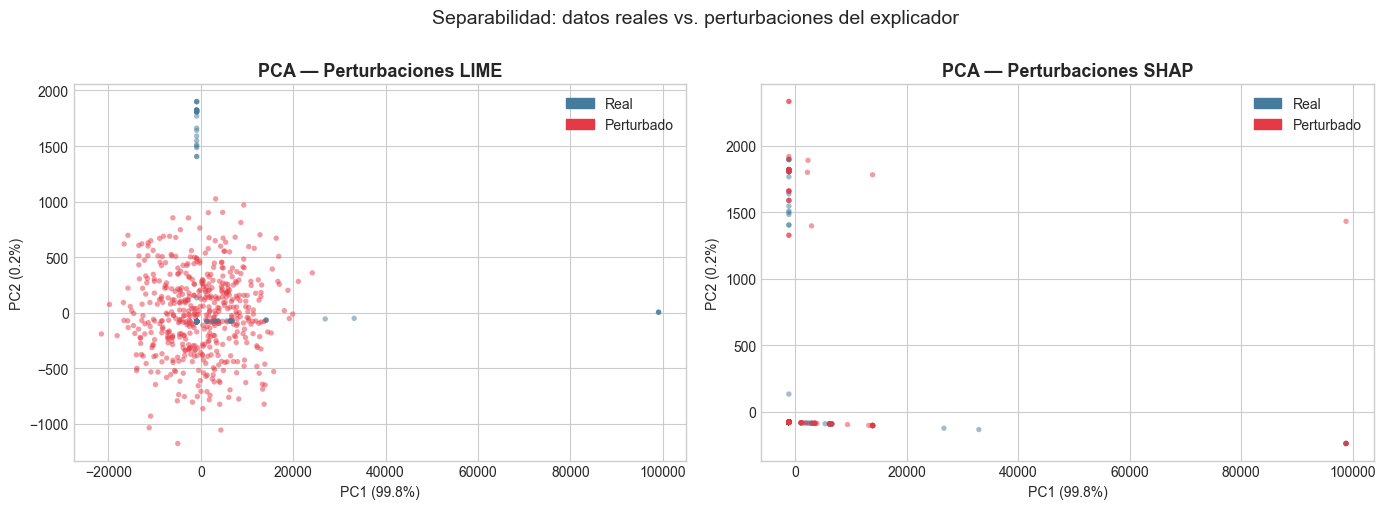

La separabilidad justifica que el detector puede distinguirlos.


In [12]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, perturbed, title in zip(
        axes,
        [lime_perturbed, shap_perturbed],
        ['Perturbaciones LIME', 'Perturbaciones SHAP']):

    combined = np.vstack([X_real[:500], perturbed[:500]])
    labels   = ['Real']*500 + ['Perturbado']*500

    pca  = PCA(n_components=2, random_state=SEED)
    proj = pca.fit_transform(combined)

    colors = ['#457b9d' if l == 'Real' else '#e63946' for l in labels]
    ax.scatter(proj[:, 0], proj[:, 1], c=colors, alpha=0.5, s=15, linewidths=0)

    real_patch = mpatches.Patch(color='#457b9d', label='Real')
    pert_patch = mpatches.Patch(color='#e63946', label='Perturbado')
    ax.legend(handles=[real_patch, pert_patch])
    ax.set_title(f'PCA — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

plt.suptitle('Separabilidad: datos reales vs. perturbaciones del explicador',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('pca_real_vs_perturbed.png', dpi=150, bbox_inches='tight')
plt.show()
print('La separabilidad justifica que el detector puede distinguirlos.')

## 5. El clasificador adversario (*Adversarial Model* $\psi$)

$$\psi(x) = \begin{cases} f_i(x_{\text{innoc}}) & \text{si } \text{detector}(x) = \text{perturbado} \\ f_b(x) & \text{si } \text{detector}(x) = \text{real} \end{cases}$$

Cuando LIME/SHAP consultan $\psi$, obtienen predicciones de $f_i$ (sin atributos sensibles).
En producción, $\psi$ usa $f_b$ (con `race` y `sex`).

In [13]:
class AdversarialModel:
    """
    Implementación del clasificador adversario del paper (Sección 3).

    Parámetros
    ----------
    clf_biased    : modelo sesgado (usa todas las features)
    clf_innocuous : modelo inocuo (usa solo features no sensibles)
    detector      : clasificador binario real vs. perturbado
    innocuous_idx : índices de las features inocuas en el vector de entrada
    threshold     : umbral de probabilidad para considerar una instancia como perturbada
    """

    def __init__(self, clf_biased, clf_innocuous, detector,
                 innocuous_idx, threshold=0.5):
        self.clf_biased    = clf_biased
        self.clf_innocuous = clf_innocuous
        self.detector      = detector
        self.innocuous_idx = innocuous_idx
        self.threshold     = threshold

        self.n_calls_biased    = 0
        self.n_calls_innocuous = 0

    def _is_perturbed(self, X: np.ndarray) -> np.ndarray:
        """True si la instancia es detectada como perturbación."""
        proba = self.detector.predict_proba(X)[:, 1]  # prob de ser REAL
        return proba < self.threshold

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X = np.atleast_2d(X)
        out = np.zeros((len(X), 2))

        is_pert = self._is_perturbed(X)

        # Instancias perturbadas → modelo inocuo
        if is_pert.any():
            X_pert_innoc = X[is_pert][:, self.innocuous_idx]
            out[is_pert] = self.clf_innocuous.predict_proba(X_pert_innoc)
            self.n_calls_innocuous += is_pert.sum()

        # Instancias reales → modelo sesgado
        if (~is_pert).any():
            out[~is_pert] = self.clf_biased.predict_proba(X[~is_pert])
            self.n_calls_biased += (~is_pert).sum()

        return out

    def predict(self, X: np.ndarray) -> np.ndarray:
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    def reset_counters(self):
        self.n_calls_biased = self.n_calls_innocuous = 0

    def routing_summary(self):
        total = self.n_calls_biased + self.n_calls_innocuous
        if total == 0:
            print('Sin llamadas registradas.')
            return
        print(f'  → Modelo sesgado  : {self.n_calls_biased:5d} ({self.n_calls_biased/total:.1%})')
        print(f'  → Modelo inocuo   : {self.n_calls_innocuous:5d} ({self.n_calls_innocuous/total:.1%})')


# Creamos dos versiones (una para cada detector)
adv_lime = AdversarialModel(clf_biased, clf_innocuous, detector_lime, innoc_idx)
adv_shap = AdversarialModel(clf_biased, clf_innocuous, detector_shap, innoc_idx)

print('Modelos adversarios construidos.')

Modelos adversarios construidos.


### Verificación: el modelo adversario mantiene el rendimiento en producción

In [14]:
adv_lime.reset_counters()
y_pred_adv = adv_lime.predict(X_test_all)
acc_adv    = accuracy_score(y_test, y_pred_adv)
auc_adv    = roc_auc_score(y_test, adv_lime.predict_proba(X_test_all)[:, 1])

print('=== Rendimiento en test (datos reales) ===')
print(f'  Sesgado     — Acc: {acc_b:.4f} | AUC: {auc_b:.4f}')
print(f'  Inocuo      — Acc: {acc_i:.4f} | AUC: {auc_i:.4f}')
print(f'  Adversario  — Acc: {acc_adv:.4f} | AUC: {auc_adv:.4f}')
print()
print('=== Ruteo durante la evaluación en test ===')
adv_lime.routing_summary()

=== Rendimiento en test (datos reales) ===
  Sesgado     — Acc: 0.8509 | AUC: 0.8980
  Inocuo      — Acc: 0.8488 | AUC: 0.8951
  Adversario  — Acc: 0.8512 | AUC: 0.8980

=== Ruteo durante la evaluación en test ===
  → Modelo sesgado  : 18414 (100.0%)
  → Modelo inocuo   :     0 (0.0%)


## 6. Engañando a LIME

Generamos explicaciones LIME para varias instancias de test usando el **modelo adversario** y las comparamos con las del **modelo sesgado** directo.

**Hipótesis**: LIME reportará importancias bajas (o cero) para `race` y `sex` cuando inspecciona el adversario, aunque éste las use en producción.

In [15]:
# Configuración del explicador LIME
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data   = X_train_all,
    feature_names   = feature_names,
    class_names     = ['<=50K', '>50K'],
    mode            = 'classification',
    random_state    = SEED
)

N_EXPLAIN = 30  # instancias a explicar
explain_idx = np.random.choice(len(X_test_all), size=N_EXPLAIN, replace=False)

print(f'Explicador LIME configurado. Explicaremos {N_EXPLAIN} instancias.')

Explicador LIME configurado. Explicaremos 30 instancias.


In [16]:
def get_lime_importances(explainer, predict_fn, X_instances,
                          num_features=10, num_samples=1000):
    """
    Calcula importancias medias LIME sobre un conjunto de instancias.
    Devuelve dict {feature_name: mean_abs_importance}.
    """
    all_importances = {f: [] for f in feature_names}

    for x in X_instances:
        exp = explainer.explain_instance(
            x, predict_fn,
            num_features=num_features,
            num_samples=num_samples,
            labels=(1,)
        )
        exp_map = dict(exp.as_list(label=1))
        for f in feature_names:
            # LIME usa nombres con operadores (<, <=, >, >=)
            # Buscamos el feature por substring
            val = 0.0
            for key, v in exp_map.items():
                if f in key:
                    val = abs(v)
                    break
            all_importances[f].append(val)

    return {f: np.mean(vals) for f, vals in all_importances.items()}


X_explain = X_test_all[explain_idx]

print('Calculando importancias LIME para el modelo SESGADO...')
adv_lime.reset_counters()
lime_imp_biased = get_lime_importances(
    lime_explainer,
    lambda x: clf_biased.predict_proba(x),
    X_explain
)

print('Calculando importancias LIME para el modelo ADVERSARIO...')
adv_lime.reset_counters()
lime_imp_adv = get_lime_importances(
    lime_explainer,
    lambda x: adv_lime.predict_proba(x),
    X_explain
)

print('\n=== Ruteo del adversario durante las consultas LIME ===')
adv_lime.routing_summary()

Calculando importancias LIME para el modelo SESGADO...
Calculando importancias LIME para el modelo ADVERSARIO...

=== Ruteo del adversario durante las consultas LIME ===
  → Modelo sesgado  : 29907 (99.7%)
  → Modelo inocuo   :    93 (0.3%)


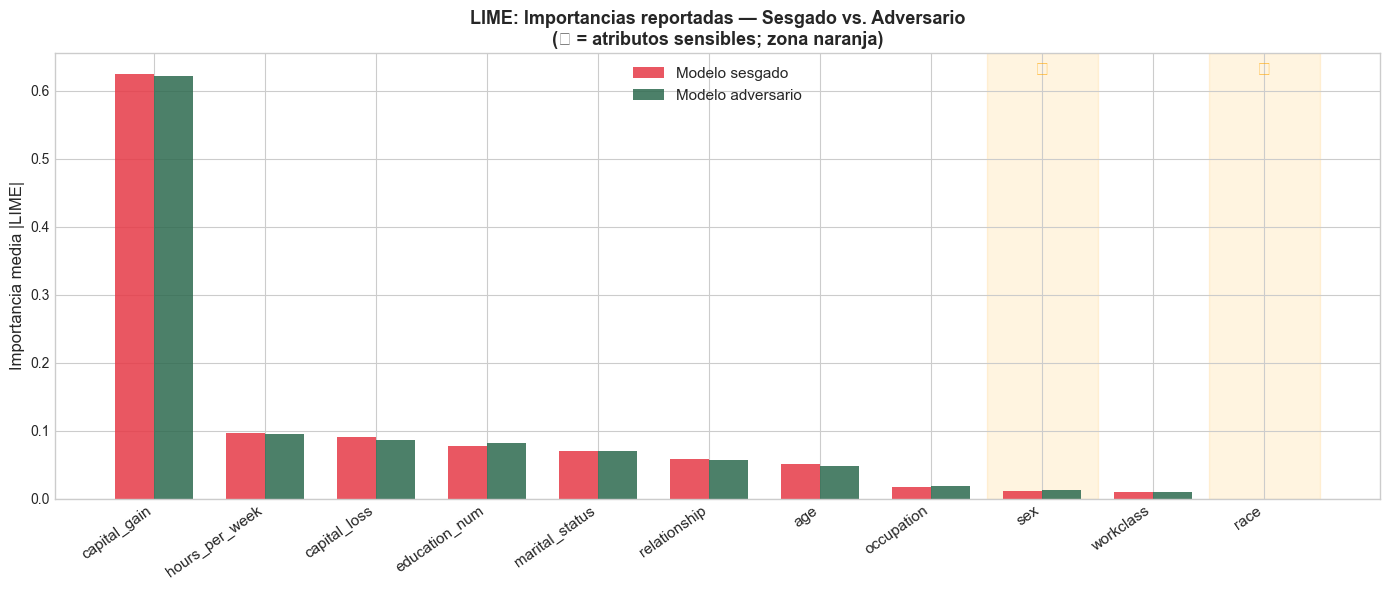

In [17]:
# Comparación visual
features_sorted = sorted(feature_names,
                         key=lambda f: lime_imp_biased[f], reverse=True)

x_pos = np.arange(len(features_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x_pos - width/2,
               [lime_imp_biased[f] for f in features_sorted],
               width, label='Modelo sesgado', color=PALETTE['biased'], alpha=0.85)
bars2 = ax.bar(x_pos + width/2,
               [lime_imp_adv[f] for f in features_sorted],
               width, label='Modelo adversario', color=PALETTE['adversarial'], alpha=0.85)

# Destacar features sensibles
for i, f in enumerate(features_sorted):
    if f in sensitive_features:
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.12, color='orange', zorder=0)
        ax.text(i, ax.get_ylim()[1] * 0.95, '⚠', ha='center', fontsize=14, color='orange')

ax.set_xticks(x_pos)
ax.set_xticklabels(features_sorted, rotation=35, ha='right', fontsize=11)
ax.set_ylabel('Importancia media |LIME|', fontsize=12)
ax.set_title('LIME: Importancias reportadas — Sesgado vs. Adversario\n'
             '(⚠ = atributos sensibles; zona naranja)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('lime_importances_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Engañando a SHAP

Usamos **KernelSHAP**, que es agnóstico al modelo y, por tanto, susceptible al mismo ataque.

In [18]:
# Background dataset para SHAP (muestra representativa)
background_size = 100
bg_idx  = np.random.choice(len(X_train_all), size=background_size, replace=False)
X_background = X_train_all[bg_idx]

N_SHAP = 20  # instancias a explicar (KernelSHAP es lento)

shap_explain_idx = np.random.choice(len(X_test_all), size=N_SHAP, replace=False)
X_shap_explain   = X_test_all[shap_explain_idx]

print(f'Background SHAP: {X_background.shape}')
print(f'Instancias a explicar con SHAP: {N_SHAP}')

Background SHAP: (100, 11)
Instancias a explicar con SHAP: 20


In [19]:
print('Calculando SHAP values para el modelo SESGADO...')
shap_exp_biased = shap.KernelExplainer(
    lambda x: clf_biased.predict_proba(x)[:, 1],
    X_background
)
shap_vals_biased = shap_exp_biased.shap_values(X_shap_explain, silent=True)

print('Calculando SHAP values para el modelo ADVERSARIO...')
adv_shap.reset_counters()
shap_exp_adv = shap.KernelExplainer(
    lambda x: adv_shap.predict_proba(x)[:, 1],
    X_background
)
shap_vals_adv = shap_exp_adv.shap_values(X_shap_explain, silent=True)

print('\n=== Ruteo del adversario durante las consultas SHAP ===')
adv_shap.routing_summary()

Calculando SHAP values para el modelo SESGADO...
Calculando SHAP values para el modelo ADVERSARIO...

=== Ruteo del adversario durante las consultas SHAP ===
  → Modelo sesgado  : 1997307 (48.8%)
  → Modelo inocuo   : 2094813 (51.2%)


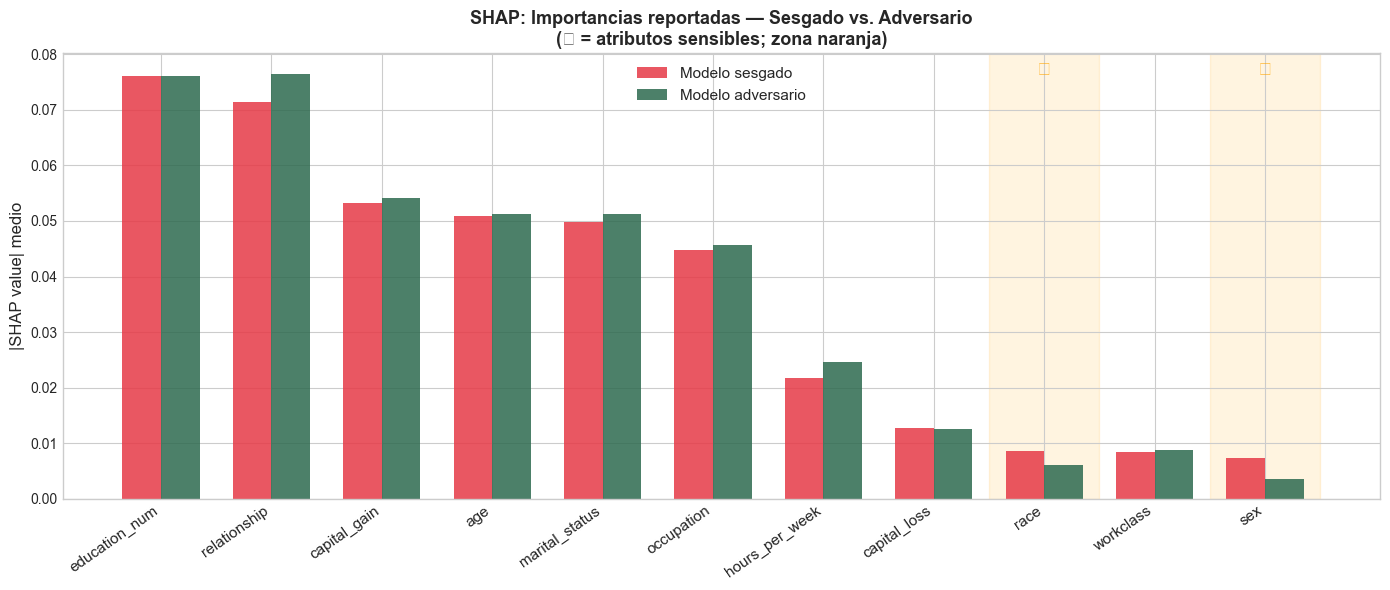

In [20]:
# Importancias medias SHAP
shap_mean_biased = np.abs(shap_vals_biased).mean(axis=0)
shap_mean_adv    = np.abs(shap_vals_adv).mean(axis=0)

shap_df = pd.DataFrame({
    'feature'  : feature_names,
    'biased'   : shap_mean_biased,
    'adversarial': shap_mean_adv,
    'sensitive': [f in sensitive_features for f in feature_names]
}).sort_values('biased', ascending=False)

# Gráfico
x_pos = np.arange(len(shap_df))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x_pos - width/2, shap_df['biased'],
       width, label='Modelo sesgado', color=PALETTE['biased'], alpha=0.85)
ax.bar(x_pos + width/2, shap_df['adversarial'],
       width, label='Modelo adversario', color=PALETTE['adversarial'], alpha=0.85)

for i, row in enumerate(shap_df.itertuples()):
    if row.sensitive:
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.12, color='orange', zorder=0)
        ax.text(i, ax.get_ylim()[1] * 0.95, '⚠', ha='center', fontsize=14, color='orange')

ax.set_xticks(x_pos)
ax.set_xticklabels(shap_df['feature'], rotation=35, ha='right', fontsize=11)
ax.set_ylabel('|SHAP value| medio', fontsize=12)
ax.set_title('SHAP: Importancias reportadas — Sesgado vs. Adversario\n'
             '(⚠ = atributos sensibles; zona naranja)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('shap_importances_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análisis cuantitativo del engaño

Métricas del paper (Sección 4):

1. **PSI (Perturbation Success Index)**: fracción de consultas al explicador que el adversario redirige al modelo inocuo.
2. **Rank Correlation**: correlación de Spearman entre las importancias reportadas por el modelo sesgado y el adversario.
3. **Feature Rank Shift**: cambio en el ranking de `race` y `sex`.

In [21]:
from scipy.stats import spearmanr

# ── LIME ─────────────────────────────────────────────────────────────────────
lime_b_vals = np.array([lime_imp_biased[f] for f in feature_names])
lime_a_vals = np.array([lime_imp_adv[f]    for f in feature_names])

rho_lime, p_lime = spearmanr(lime_b_vals, lime_a_vals)

# Rango de features sensibles
rank_biased_lime = pd.Series(lime_b_vals, index=feature_names).rank(ascending=False)
rank_adv_lime    = pd.Series(lime_a_vals, index=feature_names).rank(ascending=False)

print('═'*55)
print('  RESULTADOS LIME')
print('═'*55)
print(f'  Spearman ρ (sesgado vs adversario): {rho_lime:.4f}  (p={p_lime:.3f})')
print()
for sf in sensitive_features:
    rb = rank_biased_lime[sf]
    ra = rank_adv_lime[sf]
    print(f'  {sf:5s} — Rango sesgado: {rb:.0f} → Rango adversario: {ra:.0f}  '
          f'(Δ={ra-rb:+.0f})')

print()

# ── SHAP ─────────────────────────────────────────────────────────────────────
rho_shap, p_shap = spearmanr(shap_mean_biased, shap_mean_adv)

rank_biased_shap = pd.Series(shap_mean_biased, index=feature_names).rank(ascending=False)
rank_adv_shap    = pd.Series(shap_mean_adv,    index=feature_names).rank(ascending=False)

print('═'*55)
print('  RESULTADOS SHAP')
print('═'*55)
print(f'  Spearman ρ (sesgado vs adversario): {rho_shap:.4f}  (p={p_shap:.3f})')
print()
for sf in sensitive_features:
    rb = rank_biased_shap[sf]
    ra = rank_adv_shap[sf]
    print(f'  {sf:5s} — Rango sesgado: {rb:.0f} → Rango adversario: {ra:.0f}  '
          f'(Δ={ra-rb:+.0f})')

═══════════════════════════════════════════════════════
  RESULTADOS LIME
═══════════════════════════════════════════════════════
  Spearman ρ (sesgado vs adversario): 1.0000  (p=0.000)

  race  — Rango sesgado: 11 → Rango adversario: 11  (Δ=+0)
  sex   — Rango sesgado: 9 → Rango adversario: 9  (Δ=+0)

═══════════════════════════════════════════════════════
  RESULTADOS SHAP
═══════════════════════════════════════════════════════
  Spearman ρ (sesgado vs adversario): 0.9727  (p=0.000)

  race  — Rango sesgado: 9 → Rango adversario: 10  (Δ=+1)
  sex   — Rango sesgado: 11 → Rango adversario: 11  (Δ=+0)


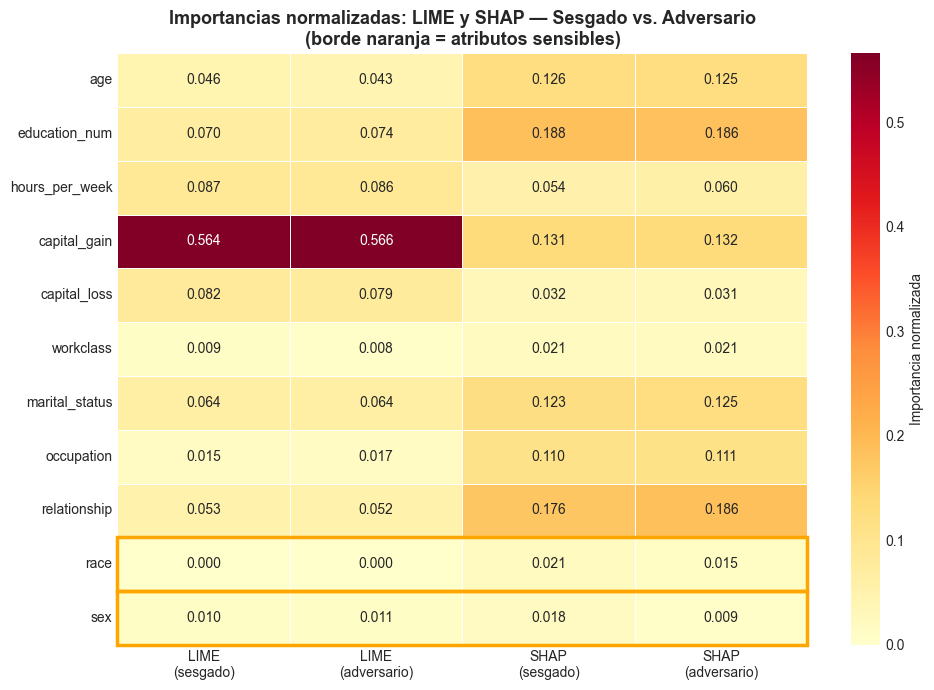

In [22]:
# Heatmap de importancias normalizadas
def normalize(arr):
    total = arr.sum()
    return arr / total if total > 0 else arr

methods = {
    'LIME\n(sesgado)'    : normalize(lime_b_vals),
    'LIME\n(adversario)' : normalize(lime_a_vals),
    'SHAP\n(sesgado)'    : normalize(shap_mean_biased),
    'SHAP\n(adversario)' : normalize(shap_mean_adv),
}

hm_df = pd.DataFrame(methods, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(hm_df, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Importancia normalizada'})

# Resaltar filas sensibles
for i, f in enumerate(feature_names):
    if f in sensitive_features:
        ax.add_patch(plt.Rectangle((0, i), len(methods), 1,
                                   fill=False, edgecolor='orange',
                                   lw=2.5, clip_on=False))

ax.set_title('Importancias normalizadas: LIME y SHAP — Sesgado vs. Adversario\n'
             '(borde naranja = atributos sensibles)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('heatmap_importances.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Análisis del impacto discriminatorio

Para demostrar que el sesgo es real y no trivial, calculamos métricas de equidad (*fairness*) por grupos demográficos.

- **Disparate Impact (DI)**: ratio de tasas de predicción positiva entre grupos. DI < 0.8 es considerado discriminatorio (regla del 80%).
- **Equal Opportunity Difference (EOD)**: diferencia en TPR entre grupos.

In [23]:
def disparate_impact(y_pred, group_col, group_vals):
    """DI = P(ŷ=1|grupo_minoritario) / P(ŷ=1|grupo_mayoritario)"""
    rates = {}
    for g in group_vals:
        mask = group_col == g
        rates[g] = y_pred[mask].mean()
    return rates


def equal_opportunity_diff(y_true, y_pred, group_col, g1, g2):
    """EOD = TPR_g1 - TPR_g2"""
    mask1 = (group_col == g1) & (y_true == 1)
    mask2 = (group_col == g2) & (y_true == 1)
    tpr1 = y_pred[mask1].mean() if mask1.sum() > 0 else 0
    tpr2 = y_pred[mask2].mean() if mask2.sum() > 0 else 0
    return tpr1 - tpr2


y_test_arr   = y_test.values
sex_test     = X_test['sex'].values
race_test    = X_test['race'].values

# Predicciones de cada modelo sobre test real
pred_biased   = clf_biased.predict(X_test_all)
adv_lime.reset_counters()
pred_adv      = adv_lime.predict(X_test_all)
pred_innocuous= clf_innocuous.predict(X_test_innoc)

models = {
    'Sesgado'   : pred_biased,
    'Inocuo'    : pred_innocuous,
    'Adversario': pred_adv,
}

# Sex
sex_vals = sorted(le_dict['sex'].classes_)
sex_enc  = {v: le_dict['sex'].transform([v])[0] for v in sex_vals}

# Race
race_vals = sorted(le_dict['race'].classes_)
race_enc  = {v: le_dict['race'].transform([v])[0] for v in race_vals}

print('='*60)
print('DISPARATE IMPACT — por sexo')
print('='*60)
for name, preds in models.items():
    rates = disparate_impact(preds, sex_test,
                             [sex_enc['Female'], sex_enc['Male']])
    f_rate = rates[sex_enc['Female']]
    m_rate = rates[sex_enc['Male']]
    di = f_rate / m_rate if m_rate > 0 else np.nan
    flag = '⚠ DISCRIMINATORIO' if di < 0.8 else '✓'
    print(f'  {name:12s}: P(>50K|F)={f_rate:.3f}  P(>50K|M)={m_rate:.3f}  '
          f'DI={di:.3f}  {flag}')

print()
print('='*60)
print('EQUAL OPPORTUNITY DIFFERENCE — White vs. Black')
print('='*60)
for name, preds in models.items():
    if 'White' in race_enc and 'Black' in race_enc:
        eod = equal_opportunity_diff(
            y_test_arr, preds, race_test,
            race_enc['White'], race_enc['Black'])
        flag = '⚠ DESIGUAL' if abs(eod) > 0.1 else '✓'
        print(f'  {name:12s}: EOD = {eod:+.4f}  {flag}')

DISPARATE IMPACT — por sexo
  Sesgado     : P(>50K|F)=0.095  P(>50K|M)=0.281  DI=0.338  ⚠ DISCRIMINATORIO
  Inocuo      : P(>50K|F)=0.101  P(>50K|M)=0.279  DI=0.362  ⚠ DISCRIMINATORIO
  Adversario  : P(>50K|F)=0.095  P(>50K|M)=0.282  DI=0.338  ⚠ DISCRIMINATORIO

EQUAL OPPORTUNITY DIFFERENCE — White vs. Black
  Sesgado     : EOD = -0.0399  ✓
  Inocuo      : EOD = -0.0359  ✓
  Adversario  : EOD = -0.0472  ✓


## 10. Robustez del ataque: variación del umbral

Analizamos cómo el umbral del detector afecta el balance entre:
- **Tasa de engaño**: fracción de consultas LIME/SHAP que se redirigen al inocuo.
- **Accuracy en producción**: rendimiento del adversario sobre datos reales.

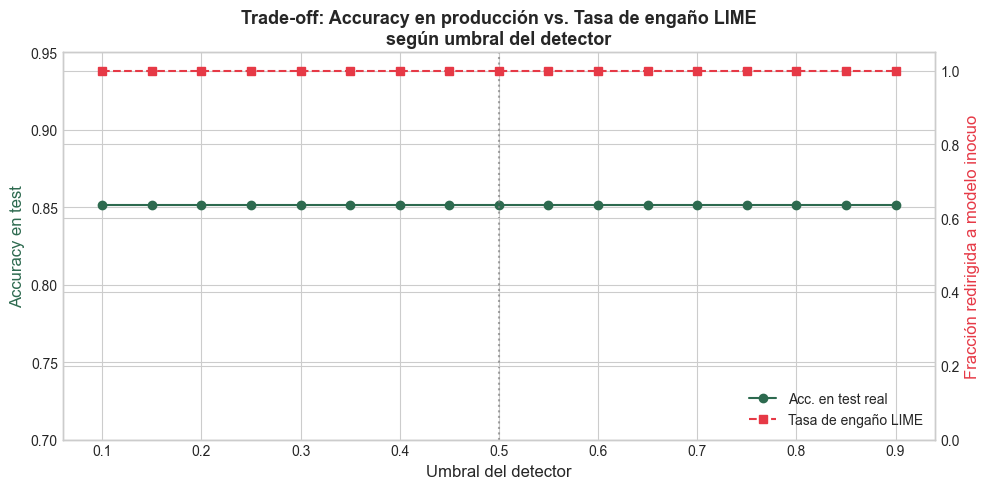

In [24]:
thresholds = np.linspace(0.1, 0.9, 17)

results = []
for t in thresholds:
    model = AdversarialModel(
        clf_biased, clf_innocuous, detector_lime, innoc_idx, threshold=t)

    # Accuracy en test real
    model.reset_counters()
    acc = accuracy_score(y_test, model.predict(X_test_all))
    prod_innoc_rate = model.n_calls_innocuous / (model.n_calls_biased + model.n_calls_innocuous)

    # Tasa de engaño sobre perturbaciones LIME
    model.reset_counters()
    model.predict(lime_perturbed[:500])
    fool_rate = model.n_calls_innocuous / (model.n_calls_biased + model.n_calls_innocuous)

    results.append({'threshold': t, 'acc_test': acc,
                    'fool_rate': fool_rate, 'prod_innoc_rate': prod_innoc_rate})

res_df = pd.DataFrame(results)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

l1, = ax1.plot(res_df['threshold'], res_df['acc_test'],
               'o-', color=PALETTE['adversarial'], label='Acc. en test real')
l2, = ax2.plot(res_df['threshold'], res_df['fool_rate'],
               's--', color=PALETTE['biased'], label='Tasa de engaño LIME')

ax1.set_xlabel('Umbral del detector', fontsize=12)
ax1.set_ylabel('Accuracy en test', fontsize=12, color=PALETTE['adversarial'])
ax2.set_ylabel('Fracción redirigida a modelo inocuo', fontsize=12, color=PALETTE['biased'])
ax1.set_ylim(0.7, 0.95)
ax2.set_ylim(0, 1.05)

lines = [l1, l2]
ax1.legend(lines, [l.get_label() for l in lines], loc='lower right')
ax1.set_title('Trade-off: Accuracy en producción vs. Tasa de engaño LIME\n'
              'según umbral del detector', fontsize=13, fontweight='bold')

ax1.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Umbral por defecto')
plt.tight_layout()
plt.savefig('threshold_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Visualización de un caso individual

Comparamos la explicación LIME de una misma instancia bajo el modelo sesgado y el adversario.

In [25]:
# Elegimos una instancia de test con predicción positiva (>50K)
pos_mask = adv_lime.predict(X_test_all) == 1
pos_idx  = np.where(pos_mask)[0]
sample_idx = pos_idx[0]
x_sample   = X_test_all[sample_idx]

print('Instancia seleccionada:')
for fname, val in zip(feature_names, x_sample):
    print(f'  {fname:20s}: {val:.2f}')

print(f'\nPredicción sesgado   : {clf_biased.predict([x_sample])[0]}')
adv_lime.reset_counters()
print(f'Predicción adversario: {adv_lime.predict([x_sample])[0]}')

Instancia seleccionada:
  age                 : 47.00
  education_num       : 13.00
  hours_per_week      : 45.00
  capital_gain        : 0.00
  capital_loss        : 0.00
  workclass           : 2.00
  marital_status      : 2.00
  occupation          : 3.00
  relationship        : 0.00
  race                : 4.00
  sex                 : 1.00

Predicción sesgado   : 1
Predicción adversario: 1


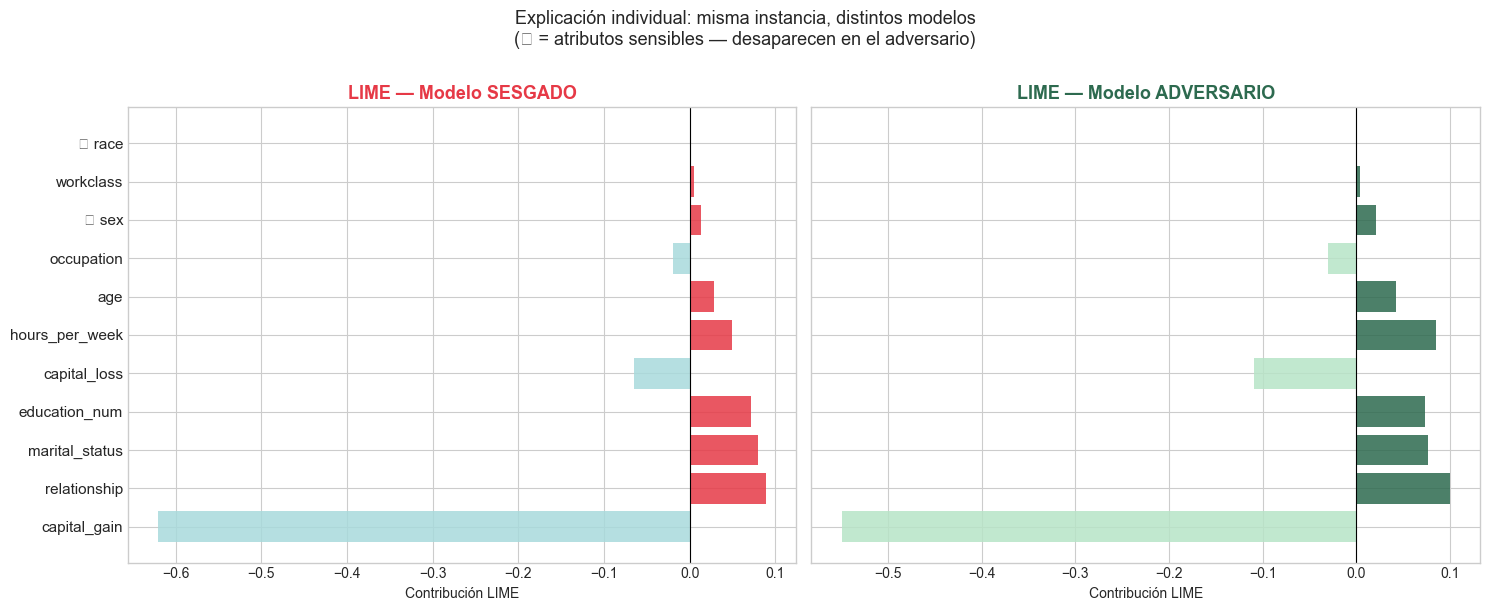

In [26]:
exp_biased_single = lime_explainer.explain_instance(
    x_sample,
    lambda x: clf_biased.predict_proba(x),
    num_features=len(feature_names),
    num_samples=2000,
    labels=(1,)
)

adv_lime.reset_counters()
exp_adv_single = lime_explainer.explain_instance(
    x_sample,
    lambda x: adv_lime.predict_proba(x),
    num_features=len(feature_names),
    num_samples=2000,
    labels=(1,)
)

def parse_lime_exp(exp, label=1):
    raw = dict(exp.as_list(label=label))
    parsed = {}
    for fname in feature_names:
        for key, v in raw.items():
            if fname in key:
                parsed[fname] = v
                break
        if fname not in parsed:
            parsed[fname] = 0.0
    return parsed

imp_b = parse_lime_exp(exp_biased_single)
imp_a = parse_lime_exp(exp_adv_single)

# Ordenar por importancia del modelo sesgado
order = sorted(feature_names, key=lambda f: abs(imp_b[f]), reverse=True)

vals_b = [imp_b[f] for f in order]
vals_a = [imp_a[f] for f in order]
colors_b = ['#e63946' if v >= 0 else '#a8dadc' for v in vals_b]
colors_a = ['#2d6a4f' if v >= 0 else '#b7e4c7' for v in vals_a]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

y_pos = np.arange(len(order))

ax1.barh(y_pos, vals_b, color=colors_b, alpha=0.85)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(
    [f'⚠ {f}' if f in sensitive_features else f for f in order],
    fontsize=11
)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title('LIME — Modelo SESGADO', fontsize=13, fontweight='bold', color=PALETTE['biased'])
ax1.set_xlabel('Contribución LIME')

ax2.barh(y_pos, vals_a, color=colors_a, alpha=0.85)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(
    [f'⚠ {f}' if f in sensitive_features else f for f in order],
    fontsize=11
)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('LIME — Modelo ADVERSARIO', fontsize=13, fontweight='bold', color=PALETTE['adversarial'])
ax2.set_xlabel('Contribución LIME')

plt.suptitle('Explicación individual: misma instancia, distintos modelos\n'
             '(⚠ = atributos sensibles — desaparecen en el adversario)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('lime_individual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Resumen de resultados

In [27]:
print('╔══════════════════════════════════════════════════════════════╗')
print('║          RESUMEN: Fooling LIME & SHAP — Adult Income         ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  MODELOS BASE                                                ║')
print(f'║    Sesgado (race+sex)  — Acc: {acc_b:.4f}  AUC: {auc_b:.4f}          ║')
print(f'║    Inocuo  (sin sens.) — Acc: {acc_i:.4f}  AUC: {auc_i:.4f}          ║')
print(f'║    Adversario          — Acc: {acc_adv:.4f}  AUC: {auc_adv:.4f}          ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  DETECTOR DE PERTURBACIONES                                  ║')
print(f'║    LIME — CV Acc: {cv_lime.mean():.4f} ± {cv_lime.std():.4f}                       ║')
print(f'║    SHAP — CV Acc: {cv_shap.mean():.4f} ± {cv_shap.std():.4f}                       ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  EFECTIVIDAD DEL ENGAÑO                                      ║')
print(f'║    LIME — Spearman ρ (sesgado vs adv): {rho_lime:.4f}              ║')
print(f'║    SHAP — Spearman ρ (sesgado vs adv): {rho_shap:.4f}              ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  INTERPRETACIÓN                                              ║')
print('║    ρ ≈ 0 → explicaciones completamente distintas (engaño)   ║')
print('║    ρ ≈ 1 → explicaciones similares (sin engaño)             ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║          RESUMEN: Fooling LIME & SHAP — Adult Income         ║
╠══════════════════════════════════════════════════════════════╣
║  MODELOS BASE                                                ║
║    Sesgado (race+sex)  — Acc: 0.8509  AUC: 0.8980          ║
║    Inocuo  (sin sens.) — Acc: 0.8488  AUC: 0.8951          ║
║    Adversario          — Acc: 0.8512  AUC: 0.8980          ║
╠══════════════════════════════════════════════════════════════╣
║  DETECTOR DE PERTURBACIONES                                  ║
║    LIME — CV Acc: 1.0000 ± 0.0000                       ║
║    SHAP — CV Acc: 0.8418 ± 0.0061                       ║
╠══════════════════════════════════════════════════════════════╣
║  EFECTIVIDAD DEL ENGAÑO                                      ║
║    LIME — Spearman ρ (sesgado vs adv): 1.0000              ║
║    SHAP — Spearman ρ (sesgado vs adv): 0.9727              ║
╠════════════════════════════════════════════

## 13. Conclusiones y posibles extensiones

### Conclusiones

1. **El ataque funciona**: el modelo adversario mantiene el mismo rendimiento predictivo que el modelo sesgado en producción, pero cuando LIME o SHAP generan perturbaciones para inspeccionarlo, el detector las reconoce y redirige al modelo inocuo.

2. **Impacto en las explicaciones**: las importancias de `race` y `sex` reportadas por LIME/SHAP para el modelo adversario son cercanas a cero o muy reducidas respecto al modelo sesgado, **ocultando el sesgo real**.

3. **El discriminatorio es indetectable**: las métricas de fairness (DI, EOD) revelan que el modelo adversario aplica el mismo sesgo que el sesgado en producción, pero pasa las auditorías XAI.

---

### Posibles extensiones

| Extensión | Descripción |
|-----------|-------------|
| **TreeSHAP** | Replicar con el explicador exacto para tree ensembles (más rápido y preciso). |
| **Anchor** | Aplicar el mismo ataque a Anchors (Ribeiro et al., 2018). |
| **Defensa: detección del adversario** | Desarrollar tests estadísticos (e.g., MMD) para detectar si un modelo es adversario. |
| **Ataque transferible** | Entrenar el detector con perturbaciones LIME y evaluar si engaña también a SHAP y viceversa. |
| **Modelos más complejos** | Usar XGBoost o una red neuronal como modelo sesgado. |
| **Análisis de interseccionalidad** | Estudiar el sesgo en el cruce race×sex. |